Year: The year that the observation was recorded

Lag1: Percentage return for previous week

Lag2: Percentage return for 2 weeks previous

Lag3: Percentage return for 3 weeks previous

Lag4: Percentage return for 4 weeks previous

Lag5: Percentage return for 5 weeks previous

Volume: Volume of shares traded (average number of daily shares traded in billions)

Today: Percentage return for this week

Direction: A factor with levels ‘Down’ and ‘Up’ indicating whether the market had a positive or negative return on a given week.

13. This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

In [44]:
from ISLP import load_data
from ISLP.models import summarize

# Import auto dataset
weekly = load_data("Weekly")
weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [45]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [46]:
weekly.shape

(1089, 9)

In [47]:
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


array([[<Axes: xlabel='Year', ylabel='Year'>,
        <Axes: xlabel='Lag1', ylabel='Year'>,
        <Axes: xlabel='Lag2', ylabel='Year'>,
        <Axes: xlabel='Lag3', ylabel='Year'>,
        <Axes: xlabel='Lag4', ylabel='Year'>,
        <Axes: xlabel='Lag5', ylabel='Year'>,
        <Axes: xlabel='Volume', ylabel='Year'>,
        <Axes: xlabel='Today', ylabel='Year'>],
       [<Axes: xlabel='Year', ylabel='Lag1'>,
        <Axes: xlabel='Lag1', ylabel='Lag1'>,
        <Axes: xlabel='Lag2', ylabel='Lag1'>,
        <Axes: xlabel='Lag3', ylabel='Lag1'>,
        <Axes: xlabel='Lag4', ylabel='Lag1'>,
        <Axes: xlabel='Lag5', ylabel='Lag1'>,
        <Axes: xlabel='Volume', ylabel='Lag1'>,
        <Axes: xlabel='Today', ylabel='Lag1'>],
       [<Axes: xlabel='Year', ylabel='Lag2'>,
        <Axes: xlabel='Lag1', ylabel='Lag2'>,
        <Axes: xlabel='Lag2', ylabel='Lag2'>,
        <Axes: xlabel='Lag3', ylabel='Lag2'>,
        <Axes: xlabel='Lag4', ylabel='Lag2'>,
        <Axes: xlabel='Lag

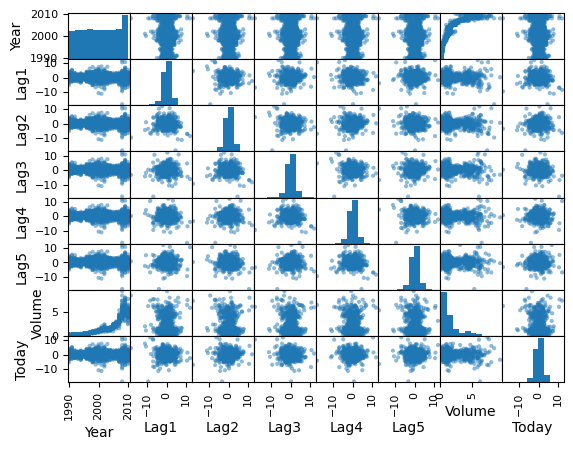

In [48]:
pd.plotting.scatter_matrix(weekly)

In [49]:
# Assuming `weekly` is your DataFrame
weekly.drop("Direction", axis=1).corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


<Axes: >

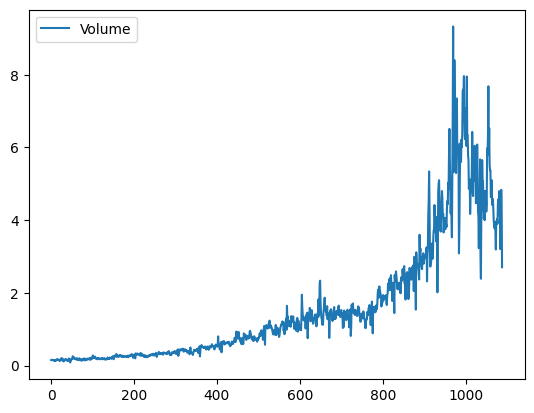

In [50]:
weekly.plot(y="Volume")

In [51]:
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


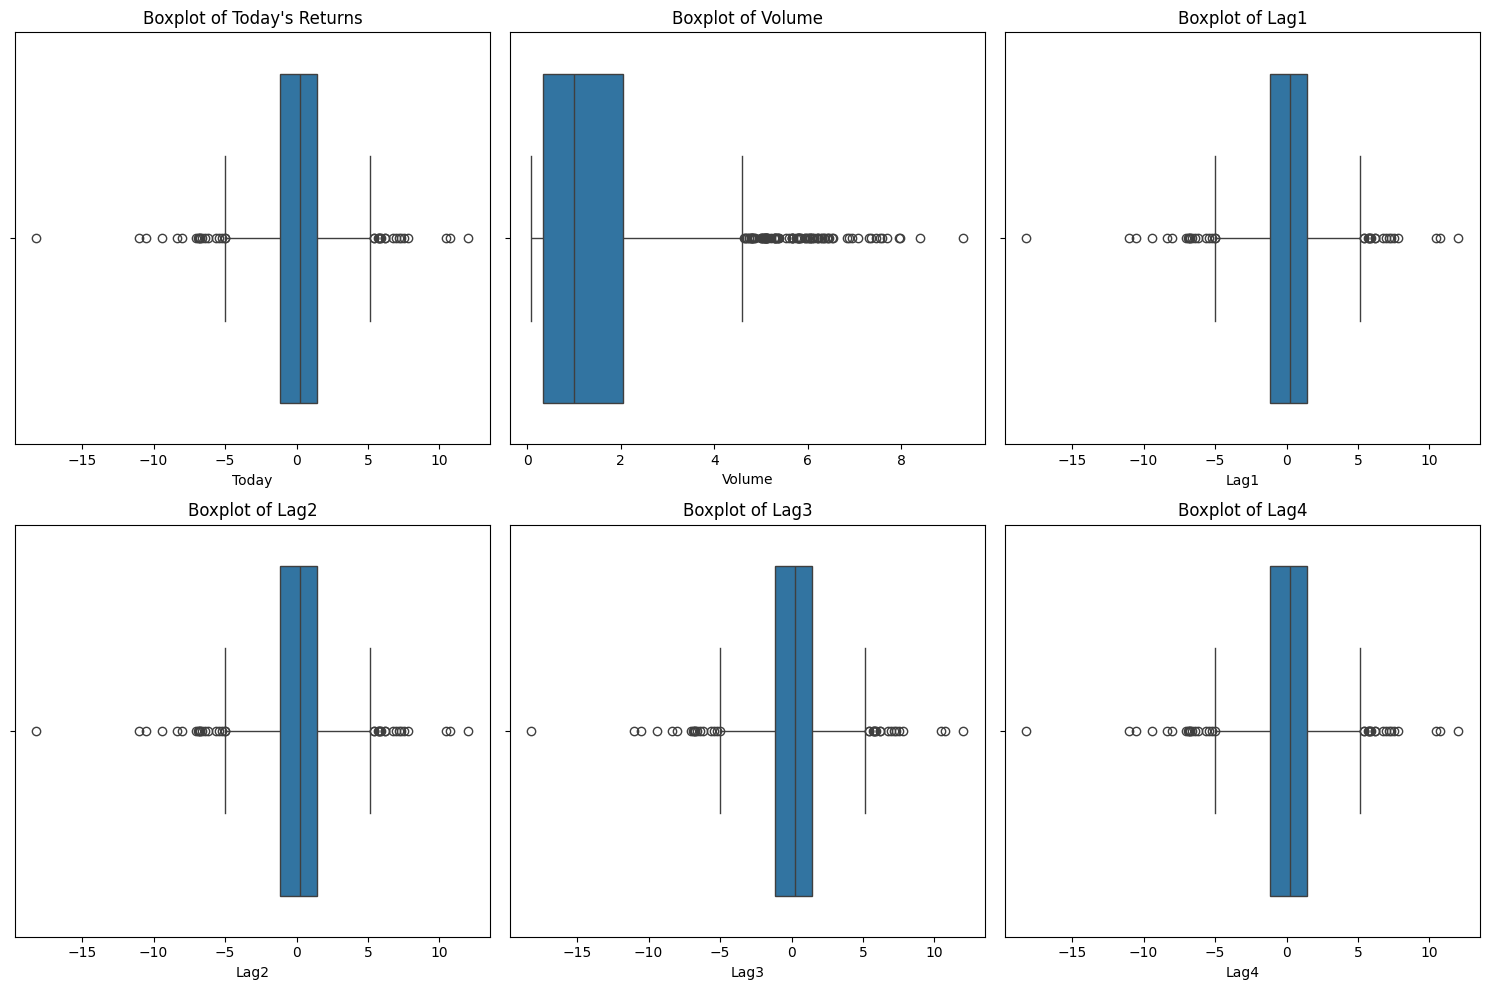

In [52]:
import seaborn as sns

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(x=weekly['Today'])
plt.title('Boxplot of Today\'s Returns')

plt.subplot(2, 3, 2)
sns.boxplot(x=weekly['Volume'])
plt.title('Boxplot of Volume')

plt.subplot(2, 3, 3)
sns.boxplot(x=weekly['Lag1'])
plt.title('Boxplot of Lag1')

plt.subplot(2, 3, 4)
sns.boxplot(x=weekly['Lag2'])
plt.title('Boxplot of Lag2')

plt.subplot(2, 3, 5)
sns.boxplot(x=weekly['Lag3'])
plt.title('Boxplot of Lag3')

plt.subplot(2, 3, 6)
sns.boxplot(x=weekly['Lag4'])
plt.title('Boxplot of Lag4')

plt.tight_layout()
plt.show()

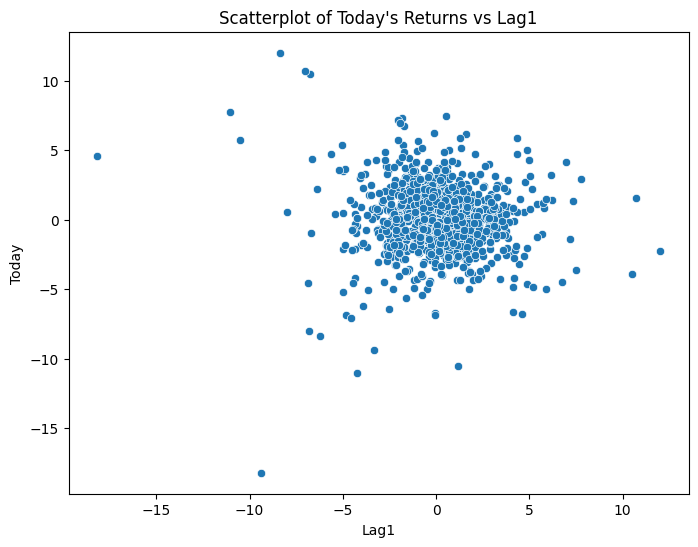

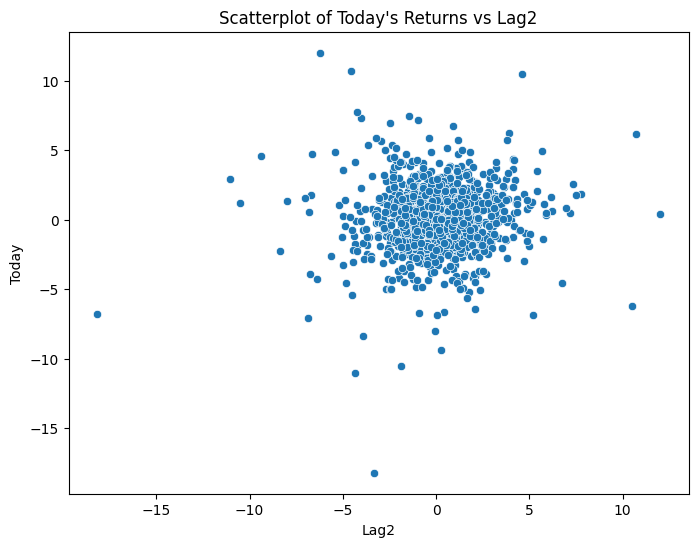

In [53]:
# Scatterplot of Today vs Lag1
plt.figure(figsize=(8, 6))
sns.scatterplot(x=weekly['Lag1'], y=weekly['Today'])
plt.title('Scatterplot of Today\'s Returns vs Lag1')
plt.xlabel('Lag1')
plt.ylabel('Today')
plt.show()

# Scatterplot of Today vs Lag2
plt.figure(figsize=(8, 6))
sns.scatterplot(x=weekly['Lag2'], y=weekly['Today'])
plt.title('Scatterplot of Today\'s Returns vs Lag2')
plt.xlabel('Lag2')
plt.ylabel('Today')
plt.show()

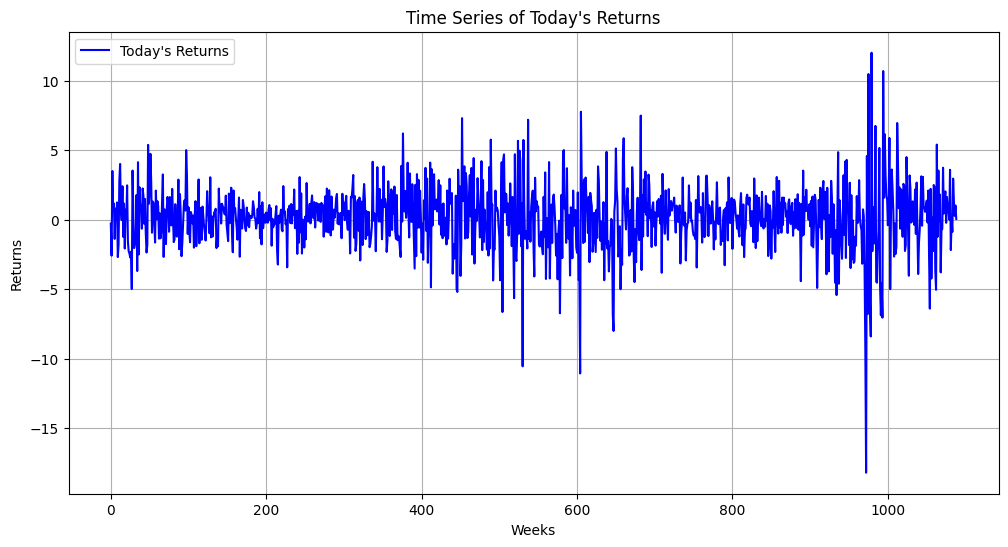

In [54]:
# Time Series plot of "Today" variable (weekly returns)
plt.figure(figsize=(12, 6))
plt.plot(weekly['Today'], label='Today\'s Returns', color='blue')
plt.title('Time Series of Today\'s Returns')
plt.xlabel('Weeks')
plt.ylabel('Returns')
plt.grid(True)
plt.legend()
plt.show()

The volume grew exponential over the years.


In [55]:
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [56]:
weekly["Direction"]

0       Down
1       Down
2         Up
3         Up
4         Up
        ... 
1084      Up
1085      Up
1086      Up
1087      Up
1088      Up
Name: Direction, Length: 1089, dtype: category
Categories (2, object): ['Down', 'Up']

In [57]:
allvars = weekly.columns.drop(["Today", "Direction", "Year"])
design = MS(allvars)
X = design.fit_transform(weekly)
y = weekly.Direction == "Up"

display(X.head())

glm = sm.GLM(y,X,family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,intercept,Lag1,Lag2,Lag3,Lag4,Lag5,Volume
0,1.0,0.816,1.572,-3.936,-0.229,-3.484,0.154976
1,1.0,-0.270,0.816,1.572,-3.936,-0.229,0.148574
2,1.0,-2.576,-0.270,0.816,1.572,-3.936,0.159837
3,1.0,3.514,-2.576,-0.270,0.816,1.572,0.161630
4,1.0,0.712,3.514,-2.576,-0.270,0.816,0.153728


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


+ Lag2
+ intercept (basic effect)

(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.

In [58]:
probs = results.predict()
labels = np.array(["Down"]*weekly.shape[0])
labels[probs > 0.5] = "Up"

In [59]:
table = confusion_table(labels, weekly.Direction)
display(table)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [60]:
np.mean(labels == weekly.Direction)

np.float64(0.5610651974288338)

The model seems to predict up movements kinda reliable, at least much more reliable than Down movements. It seems to have a tendency to just predict Up.

Based on the fraction of correct predictions, our model just seems to be slightly better than guessing (but it also already saw the test data).


Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

In [61]:
allvars = weekly.columns.drop(["Today", "Direction", "Year", "Lag1", "Lag3", "Lag4", "Lag5", "Volume"])
design = MS(allvars)
X = design.fit_transform(weekly)

In [62]:
train = (weekly.Year < 2009)
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())

display(X_train.head())
display(X_test.head())
print(X_test.shape)
print(X_test.shape)

,intercept,Lag2
0,1.0,1.572
1,1.0,0.816
2,1.0,-0.270
3,1.0,-2.576
4,1.0,3.514


,intercept,Lag2
985,1.0,-1.698
986,1.0,6.760
987,1.0,-4.448
988,1.0,-4.518
989,1.0,-2.137


(104, 2)
(104, 2)


In [63]:
results = glm_train.fit()
probs = results.predict(exog=X_test)
display(probs)

985     0.526129
986     0.644736
987     0.486216
988     0.485200
989     0.519767
          ...   
1084    0.551258
1085    0.538235
1086    0.592846
1087    0.568977
1088    0.554705
Length: 104, dtype: float64

In [64]:
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

labels = np.array(["Down"]*X_test.shape[0])
labels[probs>0.5] = "Up"

table = confusion_table(labels, L_test)
display(table)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [65]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.625), np.float64(0.375))

(e) Repeat (d) using LDA.

In [66]:
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)

In [67]:
lda = LDA(store_covariance=True)
X_train, X_test = [M.drop(columns=["intercept"]) for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [68]:
labels = lda.predict(X_test)
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

table = confusion_table(labels, L_test)
display(table)
display(np.mean(labels == L_test), np.mean(labels != L_test))

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


np.float64(0.625)

np.float64(0.375)

Repeat (d) using QDA.

In [69]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,priors,None
,reg_param,0.0
,store_covariance,True
,tol,0.0001


In [70]:
labels = qda.predict(X_test)
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

table = confusion_table(labels, L_test)
display(table)
display(np.mean(labels == L_test), np.mean(labels != L_test))

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


np.float64(0.5865384615384616)

np.float64(0.41346153846153844)

 Repeat (d) using KNN with K = 1.

In [71]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, L_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [72]:
labels = knn.predict(X_test)
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

table = confusion_table(labels, L_test)
display(table)
display(np.mean(labels == L_test), np.mean(labels != L_test))

Truth,Down,Up
Predicted,,
Down,22,32
Up,21,29


np.float64(0.49038461538461536)

np.float64(0.5096153846153846)

Repeat (d) using naive Bayes.

In [73]:
NB = GaussianNB()
NB.fit(X_train, L_train)

,priors,None
,var_smoothing,1e-09


In [74]:
labels = NB.predict(X_test)
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

table = confusion_table(labels, L_test)
display(table)
display(np.mean(labels == L_test), np.mean(labels != L_test))

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


np.float64(0.5865384615384616)

np.float64(0.41346153846153844)

Which of these methods appears to provide the best results on
this data? => LDA has the highest accuracy